In [ ]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from torchvision.models.vgg import VGG16_Weights
vgg16 = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
print(vgg16)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
from torchvision import transforms
transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),  transforms.ToTensor(),
 transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

from PIL import Image
imgs=["https://learnopencv.com/wp-content/uploads/2019/05/dog.jpg",
"https://learnopencv.com/wp-content/uploads/2021/01/strawberries.jpg",
"https://learnopencv.com/wp-content/uploads/2021/01/automotive.jpg",
"https://learnopencv.com/wp-content/uploads/2021/06/Getting_Started_with_Opencv.jpg",
"https://learnopencv.com/wp-content/uploads/2021/06/sample.jpg",
"https://t3.ftcdn.net/jpg/01/97/11/64/360_F_197116416_hpfTtXSoJMvMqU99n6hGP4xX0ejYa4M7.jpg",
"https://s1.elespanol.com/2023/03/05/madrid/capital/746185587_231400045_1706x960.jpg"]


img=[]
for im in imgs:
  !wget $im -q
  name=im.split('/')[-1]
  img.append(Image.open(name))

In [ ]:
import pandas as pd
dic=pd.read_csv('https://robertohincapie.com/data/imagenet_dict.txt', sep=':', header=None)
dic.columns=['indice','clase']
clases={}
for i in range(len(dic)):
  cad=dic.iloc[i]['clase']
  cad=cad[0:-2]
  cad=cad.replace('\'','')
  clases[dic.iloc[i]['indice']]=cad

torch.Size([7, 3, 224, 224])
torch.Size([7, 1000])
[208 949 511 610 189 610  24]


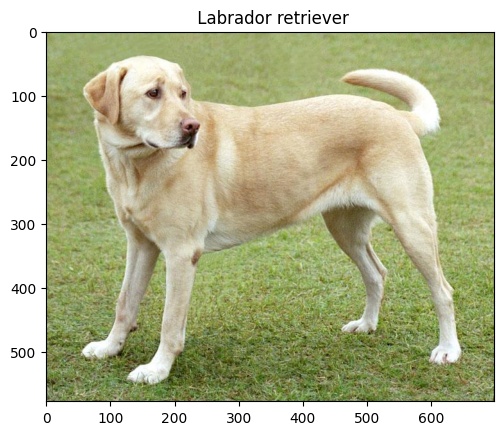

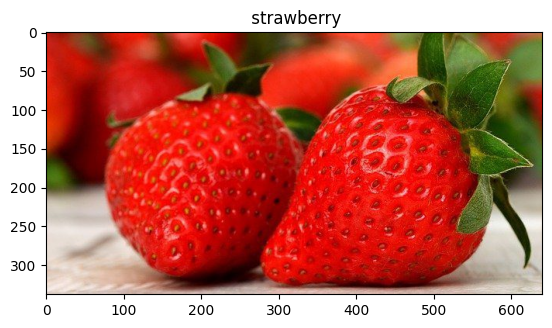

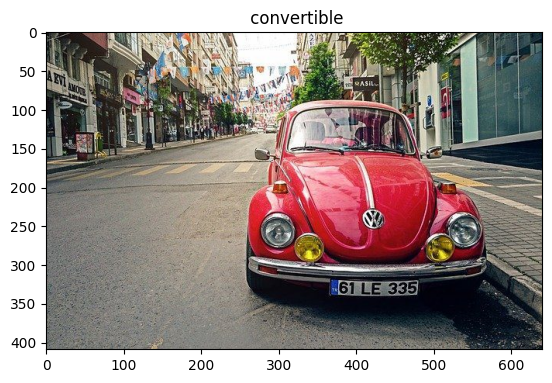

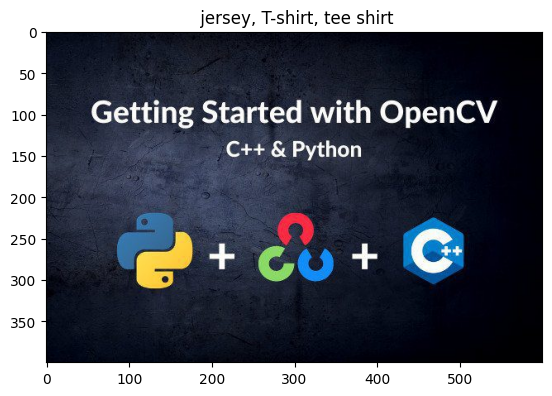

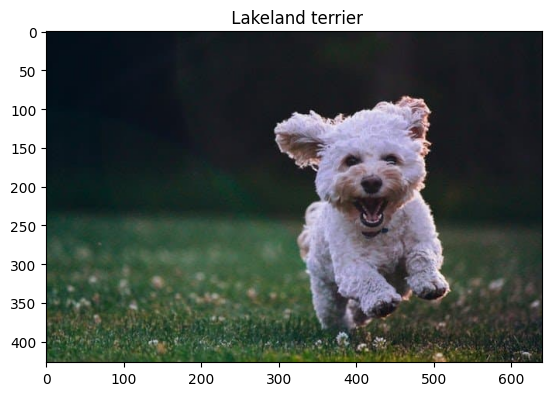

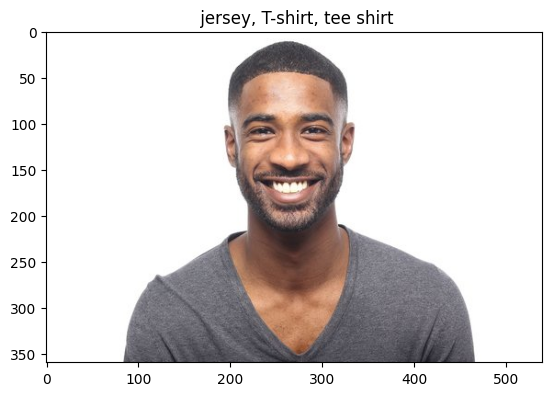

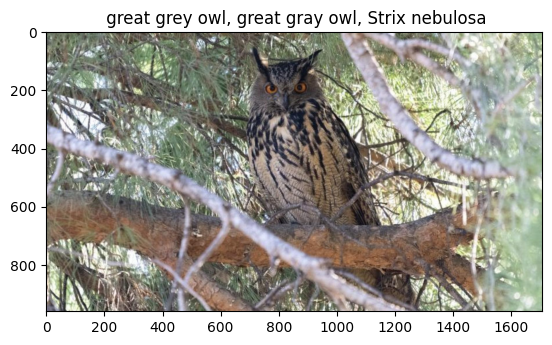

In [ ]:
batch_t=torch.cat([torch.unsqueeze(transform(im),0) for im in img], axis=0)
print(batch_t.shape)
vgg16.eval()
out = vgg16(batch_t)
print(out.shape)

_, index = torch.max(out, 1)
index=index.numpy()
print(index)
i=0
for ind in index:
  plt.figure()
  plt.imshow(img[i])
  plt.title(clases[ind])
  i+=1
